# **Notebook 3: Modelling**

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sb
import warnings as warnings

In [2]:
dataset=pd.read_csv('df_processed.csv')

In [3]:
dataset['rh']

0          94.0
1          86.7
2          74.4
3          97.0
4          93.2
           ... 
3159371    65.0
3159372    59.0
3159373    61.0
3159374    59.0
3159375    39.0
Name: rh, Length: 3159376, dtype: float64

In [4]:
X, y=dataset[['temp', 'rh', 'ws', 'precip', 'rndays']], dataset['risk_band']

In [5]:
X.head()

,temp,rh,ws,precip,rndays
0,9.5,94.0,8.6,20.52,0
1,1.0,86.7,11.1,1.71,0
2,-2.0,74.4,0.0,0.00,1
3,13.2,97.0,3.7,16.80,0
4,2.0,93.2,13.0,3.80,0


## **Train test split**

In [6]:
# How does stratify help? Ensures the training and testing sets have the same proportion of classes as the orignal dataset. Very important when dealing with inbalanced datasets. 
# Like our processed dataset that has risk_band=no_risk inflated observations
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=34, stratify=y)
X_train

,temp,rh,ws,precip,rndays
327162,20.2,65.0,13.4,14.60,0
310872,6.4,76.0,2.1,0.10,0
1899565,25.0,29.6,9.2,0.00,5
2348670,-28.0,75.5,0.0,0.01,1
1614328,25.0,45.0,4.3,0.00,9
...,...,...,...,...,...
2734004,-1.7,72.2,9.3,0.00,3
1762668,21.8,48.0,18.3,0.00,1
2625672,-0.1,50.0,9.3,0.00,5
162459,15.0,96.0,15.0,26.40,0


## **Feature Scaling**

### Since LDA/QDA/KNN and classification techniques of the like are distance/variance sensitive therefore feature scaling is important. 
### unscaled features can distort the geometry the model relies on. 

In [7]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### **Fitting Logistic Regression**

In [10]:
model_logReg=LogisticRegression(solver='lbfgs', max_iter=200)
model_logReg.fit(X_train_scaled, y_train)

KeyboardInterrupt: 

In [17]:
y_pred=model_logReg.predict(X_test_scaled)

#### Fitting a multinominal logistic regression model with and without no_risk. This was to check model performance even when an easily predictable class was not present. 

In [18]:
print(classification_report(y_test, y_pred, target_names=['extreme', 'high', 'moderate', 'no_risk', 'very_high', ]))

              precision    recall  f1-score   support

     extreme       0.78      0.65      0.71     27420
        high       0.53      0.36      0.43    137450
    moderate       0.73      0.80      0.76    352421
     no_risk       0.81      0.82      0.81    321469
   very_high       0.59      0.65      0.62    109053

    accuracy                           0.72    947813
   macro avg       0.69      0.65      0.67    947813
weighted avg       0.71      0.72      0.71    947813



#### As expected, no_risk is the best performing class with a precision of 0.81. 

In [19]:
print(classification_report(y_test, y_pred, labels=['extreme','high','moderate','very_high'], target_names=['extreme','high','moderate','very_high']))

              precision    recall  f1-score   support

     extreme       0.78      0.65      0.71     27420
        high       0.53      0.36      0.43    137450
    moderate       0.73      0.80      0.76    352421
   very_high       0.59      0.65      0.62    109053

   micro avg       0.67      0.67      0.67    626344
   macro avg       0.66      0.61      0.63    626344
weighted avg       0.66      0.67      0.66    626344



#### Whats more significant to notice is the f1 score dropping from 0.67 to 0.63. This means, no_risk was responsible of inflating the overall macro-f1 average. Excluding it reveals the models skill at distinguishing risk severities which is lower and more relecant to the projects actual goal. 

In [20]:
model_logReg_weighted=LogisticRegression(solver='lbfgs', max_iter=200, class_weight='balanced')
model_logReg_weighted.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [21]:
y_pred_weighted=model_logReg_weighted.predict(X_test_scaled)

In [22]:
print(classification_report(y_test, y_pred_weighted, target_names=['extreme', 'high', 'moderate', 'no_risk', 'very_high', ]))

              precision    recall  f1-score   support

     extreme       0.57      0.88      0.69     27420
        high       0.42      0.57      0.49    137450
    moderate       0.80      0.64      0.71    352421
     no_risk       0.82      0.81      0.81    321469
   very_high       0.55      0.62      0.59    109053

    accuracy                           0.69    947813
   macro avg       0.63      0.70      0.66    947813
weighted avg       0.72      0.69      0.70    947813



In [23]:
print(classification_report(y_test, y_pred_weighted, labels=['extreme','high','moderate','very_high'], target_names=['extreme','high','moderate','very_high']))

              precision    recall  f1-score   support

     extreme       0.57      0.88      0.69     27420
        high       0.42      0.57      0.49    137450
    moderate       0.80      0.64      0.71    352421
   very_high       0.55      0.62      0.59    109053

   micro avg       0.63      0.63      0.63    626344
   macro avg       0.59      0.68      0.62    626344
weighted avg       0.67      0.63      0.64    626344



#### our recall, that is the number of TP/TP+FN has gone up for both extreme and high. For a fire risk system this may be beneficial since the model is missing fewer real extreme days. 
#### However, it comes at the cost of lower precision for both those classes.
#### This means, higher number of false positives(false alarms) may be reported. 
#### the choice between baseline and weighted logistic regression depends on whether the project prioritizes catching more true extreme/high-risk cases or minimizing false alarms

## **Linear Discriminant analysis**

In [13]:
model_lda=LinearDiscriminantAnalysis()
model_lda.fit(X_train_scaled, y_train)
y_pred_lda=model_lda.predict(X_test_scaled)

### **LDA with and w/o no_risk, w/o priors**

In [14]:
print(classification_report(y_test, y_pred_lda, target_names=['extreme', 'high', 'moderate', 'no_risk', 'very_high']))

              precision    recall  f1-score   support

     extreme       0.70      0.32      0.44     27420
        high       0.44      0.31      0.36    137450
    moderate       0.67      0.81      0.73    352421
     no_risk       0.84      0.79      0.81    321469
   very_high       0.55      0.57      0.56    109053

    accuracy                           0.69    947813
   macro avg       0.64      0.56      0.58    947813
weighted avg       0.68      0.69      0.68    947813



### Similar problem to logistic regression but worse. no_risk is the best performing class. Performance for all other classes drops significantly. 

In [20]:
print(classification_report(y_test, y_pred_lda, labels=['extreme','high','moderate','very_high'], target_names=['extreme', 'high', 'moderate', 'very_high']))

              precision    recall  f1-score   support

     extreme       0.70      0.32      0.44     27420
        high       0.44      0.31      0.36    137450
    moderate       0.67      0.81      0.73    352421
   very_high       0.55      0.57      0.56    109053

   micro avg       0.62      0.63      0.63    626344
   macro avg       0.59      0.50      0.52    626344
weighted avg       0.60      0.63      0.61    626344



### This indicates no_risk was inflating the macro_avg value. Removing no_risk drops the value from 0.64 to 0.59. 

### **LDA with and w/o no_risk with priors**

In [15]:
model_lda_weighted=LinearDiscriminantAnalysis(priors=[0.2, 0.2, 0.2, 0.2, 0.2])
model_lda_weighted.fit(X_train_scaled, y_train)
y_pred_lda_weighted=model_lda_weighted.predict(X_test_scaled)

In [21]:
print(classification_report(y_test, y_pred_lda_weighted, target_names=['extreme', 'high', 'moderate','no_risk', 'very_high']))

              precision    recall  f1-score   support

     extreme       0.47      0.79      0.59     27420
        high       0.36      0.53      0.43    137450
    moderate       0.77      0.59      0.66    352421
     no_risk       0.84      0.78      0.81    321469
   very_high       0.51      0.61      0.55    109053

    accuracy                           0.65    947813
   macro avg       0.59      0.66      0.61    947813
weighted avg       0.69      0.65      0.67    947813



### Precision drops significantly when using weighted LDA. We artificially inflated the prior probability of features to be the same at 20% when it was actually 1%. This encourages the assumption that extreme is more common than it actually is. 
### Even though we caught far more real extreme observations(high recall) our precision dropped since we misclassified other observations as extreme  

In [22]:
print(classification_report(y_test, y_pred_lda_weighted, labels=['extreme','high','moderate','very_high'], target_names=['extreme', 'high', 'moderate', 'very_high']))

              precision    recall  f1-score   support

     extreme       0.47      0.79      0.59     27420
        high       0.36      0.53      0.43    137450
    moderate       0.77      0.59      0.66    352421
   very_high       0.51      0.61      0.55    109053

   micro avg       0.57      0.59      0.58    626344
   macro avg       0.53      0.63      0.56    626344
weighted avg       0.62      0.59      0.59    626344



### **Quadratic Discriminant analysis**

In [17]:
model_qda=QuadraticDiscriminantAnalysis()
model_qda.fit(X_train_scaled, y_train)
y_pred_qda=model_qda.predict(X_test_scaled)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [18]:
print(classification_report(y_test, y_pred_qda, target_names=['extreme', 'high', 'moderate','no_risk', 'very_high'] ))

              precision    recall  f1-score   support

     extreme       0.64      0.73      0.68     27420
        high       0.18      0.00      0.00    137450
    moderate       0.84      0.53      0.65    352421
     no_risk       0.74      0.85      0.79    321469
   very_high       0.30      0.90      0.45    109053

    accuracy                           0.61    947813
   macro avg       0.54      0.60      0.52    947813
weighted avg       0.64      0.61      0.58    947813



In [19]:
print(classification_report(y_test, y_pred_qda, labels=['extreme', 'high', 'moderate', 'very_high'] , target_names=['extreme', 'high', 'moderate','very_high'] ))

              precision    recall  f1-score   support

     extreme       0.64      0.73      0.68     27420
        high       0.18      0.00      0.00    137450
    moderate       0.84      0.53      0.65    352421
   very_high       0.30      0.90      0.45    109053

   micro avg       0.53      0.49      0.51    626344
   macro avg       0.49      0.54      0.45    626344
weighted avg       0.60      0.49      0.48    626344



#### **QDA with priors**

In [20]:
model_qda_priors=QuadraticDiscriminantAnalysis(priors=[0.2]*5)
model_qda_priors.fit(X_train_scaled, y_train)
y_pred_qda_priors=model_qda_priors.predict(X_test_scaled)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [21]:
print(classification_report(y_test, y_pred_qda_priors, target_names=['extreme', 'high', 'moderate','no_risk', 'very_high'] ))

              precision    recall  f1-score   support

     extreme       0.45      0.92      0.61     27420
        high       0.12      0.01      0.02    137450
    moderate       0.87      0.44      0.59    352421
     no_risk       0.74      0.83      0.78    321469
   very_high       0.25      0.78      0.38    109053

    accuracy                           0.56    947813
   macro avg       0.48      0.60      0.47    947813
weighted avg       0.63      0.56      0.55    947813



In [22]:
print(classification_report(y_test, y_pred_qda_priors, labels=['extreme', 'high', 'moderate', 'very_high'] , target_names=['extreme', 'high', 'moderate', 'very_high'] ))

              precision    recall  f1-score   support

     extreme       0.45      0.92      0.61     27420
        high       0.12      0.01      0.02    137450
    moderate       0.87      0.44      0.59    352421
   very_high       0.25      0.78      0.38    109053

   micro avg       0.45      0.43      0.44    626344
   macro avg       0.42      0.54      0.40    626344
weighted avg       0.58      0.43      0.43    626344



## **Nearest Neighbours**

In [ ]:
X_train_sub, X_test_sub, y_sub_train, y_sub_test=train_test_split(X_train_scaled, y_train, test_size=0.3, random_state=34, stratify=y_train)

In [32]:
k_values=[5, 10, 20, 30, 50]
results=[]

In [33]:
for k in k_values:
    neigh=KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_train_sub, y_sub_train)
    y_pred_knn=neigh.predict(X_test_scaled)

    f1_all = f1_score(y_test, y_pred_knn, average='macro')
    f1_excl = f1_score(
        y_test, y_pred_knn, average='macro',
        labels=['extreme', 'high', 'moderate', 'very_high']
    )
    results.append({'k': k, 'macro_f1_all': f1_all, 'macro_f1_excl_no_risk': f1_excl})


for r in results:
    
    print(r)

{'k': 5, 'macro_f1_all': 0.6570511351868203, 'macro_f1_excl_no_risk': 0.6208883923671001}
{'k': 10, 'macro_f1_all': 0.6733824386907873, 'macro_f1_excl_no_risk': 0.6393277162283139}
{'k': 20, 'macro_f1_all': 0.682968137369989, 'macro_f1_excl_no_risk': 0.649270951815599}
{'k': 30, 'macro_f1_all': 0.6857219840326051, 'macro_f1_excl_no_risk': 0.6521822989741644}
{'k': 50, 'macro_f1_all': 0.6878966367259315, 'macro_f1_excl_no_risk': 0.6545488732670044}


In [37]:
high_k=[70, 90, 100, 120]

In [38]:
for k in high_k:
    neigh=KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_train_sub, y_sub_train)
    y_pred_knn=neigh.predict(X_test_scaled)

    f1_all = f1_score(y_test, y_pred_knn, average='macro')
    f1_excl = f1_score(
        y_test, y_pred_knn, average='macro',
        labels=['extreme', 'high', 'moderate', 'very_high']
    )
    results.append({'k': k, 'macro_f1_all': f1_all, 'macro_f1_excl_no_risk': f1_excl})


for r in results:
    
    print(r)

{'k': 5, 'macro_f1_all': 0.6570511351868203, 'macro_f1_excl_no_risk': 0.6208883923671001}
{'k': 10, 'macro_f1_all': 0.6733824386907873, 'macro_f1_excl_no_risk': 0.6393277162283139}
{'k': 20, 'macro_f1_all': 0.682968137369989, 'macro_f1_excl_no_risk': 0.649270951815599}
{'k': 30, 'macro_f1_all': 0.6857219840326051, 'macro_f1_excl_no_risk': 0.6521822989741644}
{'k': 50, 'macro_f1_all': 0.6878966367259315, 'macro_f1_excl_no_risk': 0.6545488732670044}
{'k': 70, 'macro_f1_all': 0.6884005877632776, 'macro_f1_excl_no_risk': 0.6549552862841793}
{'k': 90, 'macro_f1_all': 0.688380564688382, 'macro_f1_excl_no_risk': 0.6548864421436362}
{'k': 100, 'macro_f1_all': 0.6885274793316447, 'macro_f1_excl_no_risk': 0.6550183148933449}
{'k': 120, 'macro_f1_all': 0.6884159370314482, 'macro_f1_excl_no_risk': 0.6548674601874411}


## As visible, the f1 value tends to rise until k=100 and then slowly starts to fall.  

In [40]:
neigh=KNeighborsClassifier(n_neighbors=100)
neigh.fit(X_train_scaled, y_train)
y_knn_pred=neigh.predict(X_test_scaled)

In [42]:
f1_all=f1_score(y_test, y_knn_pred, average='macro')
f1_excl=f1_score(y_test, y_knn_pred, average='macro', labels=['extreme', 'high', 'moderate', 'very_high'])
print(f1_all)
print(f1_excl)

0.6892053791314892
0.6558790580248952


## **Performance Summary**

In [36]:
df=pd.DataFrame({
    'Model':['KNN', 'LR(baseline)', 'LR(bal)', 'LDA(bal pr)', 'LDA(def pr)', 'QDA(def pr)', 'QDA(bal pr)'],
    'Macro_f1(all features)':[0.689, 0.67, 0.66, 0.61, 0.58, 0.54, 0.52], 
    'Macro_f1(excl no_risk)':[0.656, 0.63, 0.62, 0.56, 0.52, 0.48, 0.42]
    })
df


,Model,Macro_f1(all features),Macro_f1(excl no_risk)
0,KNN,0.689,0.656
1,LR(baseline),0.670,0.630
2,LR(bal),0.660,0.620
3,LDA(bal pr),0.610,0.560
4,LDA(def pr),0.580,0.520
5,QDA(def pr),0.540,0.480
6,QDA(bal pr),0.520,0.420


In [37]:
dfm=pd.melt(df, id_vars='Model',var_name='features', value_name='performance')
dfm

,Model,features,performance
0,KNN,Macro_f1(all features),0.689
1,LR(baseline),Macro_f1(all features),0.670
2,LR(bal),Macro_f1(all features),0.660
3,LDA(bal pr),Macro_f1(all features),0.610
4,LDA(def pr),Macro_f1(all features),0.580
5,QDA(def pr),Macro_f1(all features),0.540
6,QDA(bal pr),Macro_f1(all features),0.520
7,KNN,Macro_f1(excl no_risk),0.656
8,LR(baseline),Macro_f1(excl no_risk),0.630
9,LR(bal),Macro_f1(excl no_risk),0.620


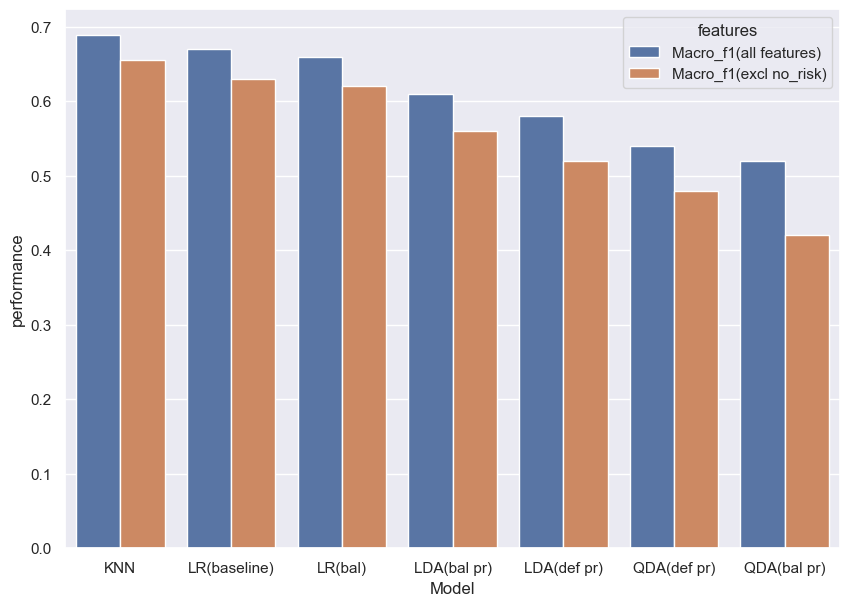

In [45]:
plt.figure(figsize=(10,7))
sb.set_style('darkgrid')
sb.despine(left=True)
ax=sb.barplot(x='Model', y='performance', hue='features', data=dfm)